In [1]:
# Colab-safe dependency bootstrap. Re-running is harmless.
import importlib, subprocess, sys

def _ensure(requirements):
    missing = []
    for module_name, pip_spec in requirements:
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(pip_spec)
    if missing:
        print("Installing:", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All dependencies already present.")

_ensure([
    ("qiskit",     "qiskit>=2.1"),
    ("qiskit_aer", "qiskit-aer>=0.15"),
    ("numpy",      "numpy"),
    ("scipy",      "scipy"),
    ("matplotlib", "matplotlib"),
    ("pylatexenc", "pylatexenc"),      # nicer circuit drawings
])

All dependencies already present.


In [2]:
from __future__ import annotations

import json
import os
import time
from dataclasses import dataclass
from typing import Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import qiskit
import qiskit_aer
import scipy
from scipy.linalg import eigvals, hankel, lstsq, svd

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import PauliEvolutionGate, UnitaryGate
from qiskit.quantum_info import (
    Operator, SparsePauliOp, Statevector, partial_trace,
)
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer import AerSimulator

print(f"qiskit      {qiskit.__version__}")
print(f"qiskit-aer  {qiskit_aer.__version__}")
print(f"numpy       {np.__version__}")
print(f"scipy       {scipy.__version__}")

_major, _minor = (int(x) for x in qiskit.__version__.split(".")[:2])
assert (_major, _minor) >= (2, 1), "This notebook targets Qiskit >= 2.1 (control-flow / primitives API)."

qiskit      2.5.1
qiskit-aer  0.17.2
numpy       2.4.6
scipy       1.17.1


In [3]:
# ----------------------------------------------------------------- experiment budget
BUDGET = "full"        # "full" = official benchmark. "fast" = half the shots, for debugging.

if BUDGET == "full":
    N_TIMES, DT, SHOTS = 64, 0.2, 2000          # official challenge budget: 256,000 shots
elif BUDGET == "fast":
    N_TIMES, DT, SHOTS = 32, 0.4, 2000          # T_max 12.4 (vs 12.6), half the shots, ~2x faster
else:
    raise ValueError(BUDGET)

SEED = 2026            # master seed -- EVERY random draw in this notebook derives from it
STRICT_CHECKS = True   # checkpoints raise on failure (set False to keep going and inspect)

TS = np.arange(N_TIMES) * DT
T_MAX = TS[-1]

print(f"budget            : {BUDGET}")
print(f"times             : N_t = {N_TIMES}, dt = {DT}, T_max = {T_MAX:.2f}")
print(f"shots per (t,phi) : {SHOTS}")
print(f"total shots       : {N_TIMES * 2 * SHOTS:,}")
print(f"Fourier resolution: 2*pi/T_max = {2 * np.pi / T_MAX:.3f}")
print(f"Nyquist window    : |E| <= pi/dt = {np.pi / DT:.2f}")
if BUDGET != "full":
    print("\nNOTE: reduced budget. Checks whose tolerance was calibrated at the official budget")
    print("      become ADVISORY; deterministic checks stay hard. Re-run at 'full' before you")
    print("      believe any number you intend to report.")

budget            : full
times             : N_t = 64, dt = 0.2, T_max = 12.60
shots per (t,phi) : 2000
total shots       : 256,000
Fourier resolution: 2*pi/T_max = 0.499
Nyquist window    : |E| <= pi/dt = 15.71


In [4]:
# ------------------------------------------------------------------- house style + checks
COL = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "violet": "#4a3aa7",
       "ink": "#0b0b0b", "muted": "#898781", "grid": "#e1e0d9", "axis": "#c3c2b7"}
BG = "#fcfcfb"

def style_axes(ax):
    """One consistent look for every figure in the notebook."""
    ax.set_facecolor(BG)
    ax.grid(True, color=COL["grid"], linewidth=0.8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(COL["axis"])
    ax.tick_params(colors=COL["muted"], labelsize=9)
    ax.xaxis.label.set_color(COL["ink"])
    ax.yaxis.label.set_color(COL["ink"])
    ax.title.set_color(COL["ink"])

plt.rcParams.update({"figure.facecolor": BG, "savefig.facecolor": BG, "figure.dpi": 110})

FIGDIR = "figures"          # every figure is written here as well as displayed
os.makedirs(FIGDIR, exist_ok=True)

def show(fig, name: str):
    """Display a figure AND save it -- §10.1 asks for these plots as deliverables."""
    fig.savefig(f"{FIGDIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


CHECK_LOG: list[tuple[str, bool, str, bool]] = []

def check(name: str, ok: bool, detail: str = "", soft: bool = False,
          budget_sensitive: bool = False) -> bool:
    """Record and report a checkpoint.

    soft=True             ADVISORY always: reported, never raises. Used for quantities that are
                          genuinely stochastic run to run (the Krylov GEVP is the honest example).
    budget_sensitive=True ADVISORY only when BUDGET != "full", because the tolerance was
                          calibrated at the official shot budget.

    Deterministic checks -- conventions, bit ordering, operator identities -- are neither, so
    they stay HARD at every budget. A green notebook at BUDGET="fast" still proves your circuit
    and your endianness are right; it does not prove your statistics.
    """
    ok = bool(ok)
    soft = soft or (budget_sensitive and BUDGET != "full")
    CHECK_LOG.append((name, ok, detail, soft))
    tag = "PASS" if ok else ("warn" if soft else "FAIL")
    print(f"{tag:>4}  |  {name}" + (f"   ({detail})" if detail else ""))
    if not ok and not soft and STRICT_CHECKS:
        raise AssertionError(f"checkpoint failed: {name} {detail}")
    return ok


def sub_seed(tag: str, index: int = 0) -> int:
    """A reproducible, well-separated seed for `tag`, derived from the master SEED.

    Note we use zlib.crc32, NOT Python's hash(): hash() of a str is randomised per process
    (PYTHONHASHSEED), which would silently destroy reproducibility between runs.
    """
    import zlib
    entropy = [SEED, zlib.crc32(tag.encode()) % (2 ** 31), index]
    return int(np.random.SeedSequence(entropy).generate_state(1)[0]) % (2 ** 31)

def sigma_gate(estimate: float, reference: float, sem: float, n_sigma: float = 5.0):
    """Standard acceptance test used throughout: |est - ref| < n_sigma * sem."""
    dev = abs(estimate - reference)
    z = dev / sem if sem > 0 else np.inf
    return z < n_sigma, f"{estimate:+.4f} vs {reference:+.4f}, {z:.1f} sigma"

print("style + checkpoint helpers ready")

style + checkpoint helpers ready


In [5]:
N_SYS = 3                       # system qubits; the ancilla is one extra qubit (index N_SYS)
PHI_RE, PHI_IM = 0.0, -np.pi / 2   # the two quadrature settings

PAULI_CODES = {"X": 0, "Y": 1, "Z": 2}
CODE_TO_PAULI = "XYZ"


def benchmark_hamiltonian() -> SparsePauliOp:
    """H = 0.65 sum (XX + YY) + 0.25 sum ZZ + 0.40 Z0 - 0.50 Z1 + 0.15 Z2 (open chain)."""
    terms = []
    for i in range(N_SYS - 1):
        terms += [("XX", [i, i + 1], 0.65), ("YY", [i, i + 1], 0.65), ("ZZ", [i, i + 1], 0.25)]
    terms += [("Z", [0], 0.40), ("Z", [1], -0.50), ("Z", [2], 0.15)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=N_SYS).simplify()


def conserved_charge() -> SparsePauliOp:
    """Q = Z_0 + Z_1 + Z_2, the total magnetisation.  [H, Q] = 0."""
    return SparsePauliOp.from_sparse_list(
        [("Z", [j], 1.0) for j in range(N_SYS)], num_qubits=N_SYS)


def state_prep_circuit() -> QuantumCircuit:
    """|psi> = Ry(1.3) on qubit 0, applied to |000>."""
    qc = QuantumCircuit(N_SYS, name="prep")
    qc.ry(1.3, 0)
    return qc


HAM = benchmark_hamiltonian()
CHARGE = conserved_charge()
Z0_OBS = SparsePauliOp.from_sparse_list([("Z", [0], 1.0)], num_qubits=N_SYS)   # NOT conserved

print("H =", HAM)
print()
print("Q =", CHARGE)

H = SparsePauliOp(['IXX', 'IYY', 'IZZ', 'XXI', 'YYI', 'ZZI', 'IIZ', 'IZI', 'ZII'],
              coeffs=[ 0.65+0.j,  0.65+0.j,  0.25+0.j,  0.65+0.j,  0.65+0.j,  0.25+0.j,
  0.4 +0.j, -0.5 +0.j,  0.15+0.j])

Q = SparsePauliOp(['IIZ', 'IZI', 'ZII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


In [6]:
def exact_state(prep: QuantumCircuit | None = None) -> np.ndarray:
    return np.asarray(Statevector(prep if prep is not None else state_prep_circuit()).data)


@dataclass
class ExactSpectrum:
    """Symmetry-resolved exact eigensystem of (H, Q) plus the populations of |psi>."""
    energies: np.ndarray      # (2**n,)
    charges: np.ndarray       # (2**n,) integer Q labels
    populations: np.ndarray   # (2**n,) p_k = |<E_k, q_k | psi>|^2

    def populated(self, threshold: float = 1e-10):
        m = self.populations > threshold
        return self.energies[m], self.charges[m], self.populations[m]


def exact_spectrum(ham=None, charge=None, psi=None) -> ExactSpectrum:
    """Block-diagonalise H inside each Q sector -> a common (H, Q) eigenbasis."""
    ham = ham if ham is not None else HAM
    charge = charge if charge is not None else CHARGE
    psi = psi if psi is not None else exact_state()
    hmat = ham.to_matrix()
    qdiag = np.real(np.diag(charge.to_matrix()))
    energies, charges, pops = [], [], []
    for q in sorted(set(np.round(qdiag).astype(int))):
        idx = np.where(np.round(qdiag).astype(int) == q)[0]
        evals, evecs = np.linalg.eigh(hmat[np.ix_(idx, idx)])
        amps = evecs.conj().T @ psi[idx]
        energies += list(evals)
        charges += [q] * len(idx)
        pops += list(np.abs(amps) ** 2)
    order = np.argsort(energies)
    return ExactSpectrum(np.array(energies)[order],
                         np.array(charges)[order],
                         np.array(pops)[order])


def exact_unitary(ham: SparsePauliOp, t: float) -> np.ndarray:
    """U(t) = exp(-i H t) by eigendecomposition (exact for any t)."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    return (evecs * np.exp(-1j * evals * t)) @ evecs.conj().T


def exact_chi(ham, psi, ts) -> np.ndarray:
    """chi(t) = <psi| e^{-iHt} |psi> = sum_k p_k e^{-i E_k t}."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    p = np.abs(evecs.conj().T @ psi) ** 2
    return np.exp(-1j * np.outer(np.asarray(ts), evals)) @ p


def exact_chi_O(ham, psi, obs: SparsePauliOp, ts) -> np.ndarray:
    """chi_O(t) = Tr[O U(t) |psi><psi|] = <psi| O U(t) |psi>."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    phi_o = obs.to_matrix().conj().T @ psi          # O is Hermitian
    weights = np.conj(evecs.conj().T @ phi_o) * (evecs.conj().T @ psi)
    return np.exp(-1j * np.outer(np.asarray(ts), evals)) @ weights


def exact_system_marginal_expectation(ham, psi, obs: SparsePauliOp, t: float) -> float:
    """Tr[O rho^(I)(t)] with rho^(I) = (rho + U rho U^dag)/2  -- Eq. (D1)."""
    psi_t = exact_unitary(ham, t) @ psi
    omat = obs.to_matrix()
    return float(0.5 * np.real(psi.conj() @ omat @ psi + psi_t.conj() @ omat @ psi_t))


PSI = exact_state()
SPEC = exact_spectrum()
E_EXACT, Q_EXACT_LABELS, P_EXACT = SPEC.populated(1e-6)

H_EXPECT_EXACT = float(np.real(PSI.conj() @ HAM.to_matrix() @ PSI))
Q_EXPECT_EXACT = float(np.real(PSI.conj() @ CHARGE.to_matrix() @ PSI))

print("Populated levels of |psi>  (these are the four lines you must recover):\n")
print("      E_k        q_k       p_k")
for e, q, p in zip(E_EXACT, Q_EXACT_LABELS, P_EXACT):
    print(f"   {e:+9.4f}   {q:+4d}    {p:.4f}")
print(f"\n<H> = {H_EXPECT_EXACT:+.6f}      <Q> = {Q_EXPECT_EXACT:+.6f}")
print(f"full spectral radius   = {np.max(np.abs(SPEC.energies)):.3f}")
print(f"populated-line radius  = {np.max(np.abs(E_EXACT)):.3f}")
print(f"min populated spacing  = {np.min(np.diff(np.sort(E_EXACT))):.3f}")

Populated levels of |psi>  (these are the four lines you must recover):

      E_k        q_k       p_k
     -1.9152     +1    0.1597
     -0.4810     +1    0.1527
     +0.5500     +3    0.6337
     +1.9463     +1    0.0538

<H> = +0.073874      <Q> = +2.267499
full spectral radius   = 2.635
populated-line radius  = 1.946
min populated spacing  = 1.031


In [7]:
# ---------------------------------------------------- CHECKPOINT 2: the model is what we claim
h_mat, q_mat = HAM.to_matrix(), CHARGE.to_matrix()

check("[H, Q] = 0 exactly",
      np.linalg.norm(h_mat @ q_mat - q_mat @ h_mat) < 1e-12,
      f"||[H,Q]|| = {np.linalg.norm(h_mat @ q_mat - q_mat @ h_mat):.2e}")

check("populations sum to 1",
      np.isclose(SPEC.populations.sum(), 1.0, atol=1e-10))

check("exactly four populated levels", len(E_EXACT) == 4, f"got {len(E_EXACT)}")

check("populated sectors are {+1, +3}",
      set(np.round(Q_EXACT_LABELS).astype(int)) == {1, 3})

check("|000> is an exact eigenstate at E = 0.55",
      np.isclose(E_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3][0], 0.55, atol=1e-12))

check("Q=3 weight equals cos^2(0.65)",
      np.isclose(P_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3].sum(),
                 np.cos(0.65) ** 2, atol=1e-10),
      f"{P_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3].sum():.6f}")

check("no aliasing at this dt",
      np.max(np.abs(SPEC.energies)) < np.pi / DT,
      f"radius {np.max(np.abs(SPEC.energies)):.2f} < Nyquist {np.pi / DT:.2f}")

check("populated lines are Fourier-resolvable",
      np.min(np.diff(np.sort(E_EXACT))) > 2 * np.pi / T_MAX,
      f"spacing {np.min(np.diff(np.sort(E_EXACT))):.2f} > resolution {2 * np.pi / T_MAX:.2f}")

PASS  |  [H, Q] = 0 exactly   (||[H,Q]|| = 0.00e+00)
PASS  |  populations sum to 1
PASS  |  exactly four populated levels   (got 4)
PASS  |  populated sectors are {+1, +3}
PASS  |  |000> is an exact eigenstate at E = 0.55
PASS  |  Q=3 weight equals cos^2(0.65)   (0.633749)
PASS  |  no aliasing at this dt   (radius 2.64 < Nyquist 15.71)
PASS  |  populated lines are Fourier-resolvable   (spacing 1.03 > resolution 0.50)


True

In [8]:
def build_controlled_evolution(ham: SparsePauliOp, t: float,
                               method: str = "exact", reps: int = 2) -> Gate:
    """Controlled-U(t) whose FIRST qubit is the ancilla control.

    method="exact"   : the block unitary |0><0| (x) I + |1><1| (x) e^{-iHt}, built numerically.
                       Simulator-only, zero Trotter error -- use this for validation.
    method="trotter" : synthesise the 2nd-order Suzuki-Trotter product formula FIRST, then
                       control the whole synthesised circuit.  Hardware-realistic.

    Append with:  qc.append(gate, [ancilla, sys_0, ..., sys_{n-1}]).
    """
    n = ham.num_qubits

    if method == "exact":
        from scipy.linalg import expm
        u = expm(-1j * ham.to_matrix() * t)
        d = 2 ** n
        p0, p1 = np.diag([1.0, 0.0]), np.diag([0.0, 1.0])
        # qargs = [anc, s0, ..., s_{n-1}] -> ancilla is the LOWEST matrix bit
        cu = np.kron(np.eye(d), p0) + np.kron(u, p1)
        return UnitaryGate(cu, label=f"c-U(exact,t={t:.3g})")

    elif method == "trotter":
        evo = PauliEvolutionGate(ham, time=t, synthesis=SuzukiTrotter(order=2, reps=reps))
        uncontrolled = QuantumCircuit(n)
        uncontrolled.append(evo, range(n))
        uncontrolled = transpile(uncontrolled, basis_gates=["rz", "sx", "x", "cx"],
                                 optimization_level=1, seed_transpiler=0)
        # synthesise FIRST, control SECOND -- controlling the already-synthesised circuit
        # keeps the ancilla branch |0><0|(x)I + |1><1|(x)U_trot exact.
        return uncontrolled.to_gate(label=f"cU_trot(t={t:.3g},r={reps})").control(1)

    else:
        raise ValueError(f"unknown method {method!r}")

Trotter reps=1 -- as built : depth   5   {'h': 4, 'measure': 4, 'ry': 1, 'ccircuit-54': 1, 'p': 1, 'sdg': 1}
               -- transpiled: depth 664   294 CX   (this is the number that matters)


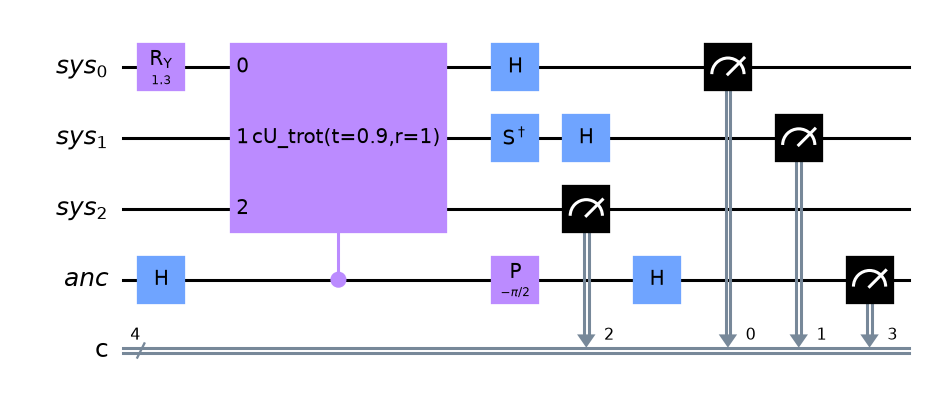

In [9]:
def build_shadow_hadamard_circuit(ham: SparsePauliOp, t: float, phi: float,
                                  basis: Sequence[int] | None,
                                  prep: QuantumCircuit | None = None,
                                  method: str = "exact", reps: int = 2,
                                  measure: bool = True) -> QuantumCircuit:
    """Hadamard test + randomised local-Pauli measurement of the system register."""
    n = ham.num_qubits
    prep = prep if prep is not None else state_prep_circuit()
    sys_reg = QuantumRegister(n, "sys")
    anc_reg = QuantumRegister(1, "anc")
    qc = QuantumCircuit(sys_reg, anc_reg)

    qc.compose(prep, qubits=sys_reg, inplace=True)          # |psi>
    qc.h(anc_reg[0])                                        # ancilla -> |+>
    qc.append(build_controlled_evolution(ham, t, method, reps), [anc_reg[0], *sys_reg])
    if phi != 0.0:
        qc.p(phi, anc_reg[0])                               # quadrature selector
    qc.h(anc_reg[0])                                        # interfere

    if basis is not None:                                   # shadow basis rotation
        for j, b in enumerate(basis):
            if b == 0:            # X basis
                qc.h(sys_reg[j])
            elif b == 1:          # Y basis
                qc.sdg(sys_reg[j])
                qc.h(sys_reg[j])
            # b == 2 (Z basis): nothing to do

    if measure:
        creg = ClassicalRegister(n + 1, "c")
        qc.add_register(creg)
        for j in range(n):
            qc.measure(sys_reg[j], creg[j])                 # c[j] <- system qubit j
        qc.measure(anc_reg[0], creg[n])                     # c[n] <- ancilla
    return qc


demo = build_shadow_hadamard_circuit(HAM, 0.9, PHI_IM, basis=[0, 1, 2], method="trotter", reps=1)
_demo_t = transpile(demo, basis_gates=["rz", "sx", "x", "cx"], optimization_level=1,
                    seed_transpiler=0)
print(f"Trotter reps=1 -- as built : depth {demo.depth():3d}   {dict(demo.count_ops())}")
print(f"               -- transpiled: depth {_demo_t.depth():3d}   "
      f"{_demo_t.count_ops().get('cx', 0)} CX   (this is the number that matters)")

# §10.1 asks for circuit diagrams of BOTH quadratures -- save them while we are here
for _name, _phi in (("phi_0_real", PHI_RE), ("phi_-pi2_imag", PHI_IM)):
    _f = build_shadow_hadamard_circuit(HAM, 0.9, _phi, basis=[0, 1, 2],
                                       method="trotter", reps=1).draw("mpl", fold=-1,
                                                                      style="clifford")
    _f.savefig(f"{FIGDIR}/03_circuit_{_name}.png", dpi=200, bbox_inches="tight")
    plt.close(_f)

demo.draw("mpl", fold=-1, style="clifford")

In [10]:
# ------------------------------------------------- CHECKPOINT 3a: the circuit is the right one
def _embed_controlled(u: np.ndarray) -> np.ndarray:
    """|0><0|_anc (x) I + |1><1|_anc (x) U with the ancilla as qubit 3 (highest)."""
    p0, p1 = np.diag([1.0, 0.0]), np.diag([0.0, 1.0])
    return np.kron(p0, np.eye(u.shape[0])) + np.kron(p1, u)


t_test = 0.73
qc_ex = QuantumCircuit(4)
qc_ex.append(build_controlled_evolution(HAM, t_test, "exact"), [3, 0, 1, 2])
_blk = _embed_controlled(exact_unitary(HAM, t_test))
check("c-U(exact) equals the block matrix",
      np.allclose(Operator(qc_ex).data, _blk, atol=1e-10),
      f"max |c-U - block| = {np.abs(Operator(qc_ex).data - _blk).max():.2e}  "
      f"(swapped kron factors put the ancilla in the wrong slot; a sign error in exp(-iHt) "
      f"leaves the diagonal block right and the controlled block conjugated)")

# Trotter path: exactly controlled, and converging in reps
errs = []
for reps in (1, 2, 8):
    qc_tr = QuantumCircuit(4)
    qc_tr.append(build_controlled_evolution(HAM, 1.1, "trotter", reps=reps), [3, 0, 1, 2])
    errs.append(np.linalg.norm(Operator(qc_tr).data - _embed_controlled(exact_unitary(HAM, 1.1)), 2))
check("Trotter error decreases with reps", errs[2] < errs[1] < errs[0],
      "  ".join(f"reps={r}: {e:.2e}" for r, e in zip((1, 2, 8), errs)))
check("2nd-order Trotter at reps=8 is accurate", errs[2] < 2e-2, f"{errs[2]:.2e}")

PASS  |  c-U(exact) equals the block matrix   (max |c-U - block| = 6.87e-16  (swapped kron factors put the ancilla in the wrong slot; a sign error in exp(-iHt) leaves the diagonal block right and the controlled block conjugated))
PASS  |  Trotter error decreases with reps   (reps=1: 8.22e-01  reps=2: 1.68e-01  reps=8: 9.67e-03)
PASS  |  2nd-order Trotter at reps=8 is accurate   (9.67e-03)


True

In [11]:
# ------------------------------------------- CHECKPOINT 3b: every sign convention, exactly
z_anc_1q = SparsePauliOp.from_sparse_list([("Z", [0], 1.0)], num_qubits=1)
test_obs = {
    "I":    SparsePauliOp.from_sparse_list([("I", [0], 1.0)], num_qubits=N_SYS),
    "Z0":   Z0_OBS,
    "Q":    CHARGE,
    "H":    HAM,
    "X0X1": SparsePauliOp.from_sparse_list([("XX", [0, 1], 1.0)], num_qubits=N_SYS),
}

worst = 0.0
for t in (0.0, 0.7, 2.3):
    for phi in (PHI_RE, PHI_IM):
        sv = Statevector(build_shadow_hadamard_circuit(HAM, t, phi, basis=None, measure=False))
        for name, obs in test_obs.items():
            joint = z_anc_1q.tensor(obs)                    # ancilla = highest qubit
            measured = float(np.real(sv.expectation_value(joint)))
            expected = float(np.real(np.exp(1j * phi) * exact_chi_O(HAM, PSI, obs, [t])[0]))
            worst = max(worst, abs(measured - expected))

check("<Z_anc (x) O>_phi = Re[e^{i phi} Tr(O U rho)]  for all (t, phi, O)",
      worst < 1e-10, f"max deviation {worst:.2e}")

# the (D1) marginal: tracing out the ancilla gives (rho + U rho U+)/2, independent of phi
sv = Statevector(build_shadow_hadamard_circuit(HAM, 1.3, PHI_IM, basis=None, measure=False))
rho_sys = partial_trace(sv, [N_SYS]).data
u13 = exact_unitary(HAM, 1.3)
rho0 = np.outer(PSI, PSI.conj())
check("tr_anc(rho_out) = (rho + U rho U+)/2   [Eq. D1]",
      np.allclose(rho_sys, 0.5 * (rho0 + u13 @ rho0 @ u13.conj().T), atol=1e-10),
      f"||diff|| = {np.linalg.norm(rho_sys - 0.5 * (rho0 + u13 @ rho0 @ u13.conj().T)):.2e}")

# the shadow basis rotation must not disturb the ancilla marginal
p_plain = Statevector(
    build_shadow_hadamard_circuit(HAM, 0.9, PHI_RE, basis=None, measure=False)).probabilities([N_SYS])
ok_rot = all(np.allclose(p_plain, Statevector(
    build_shadow_hadamard_circuit(HAM, 0.9, PHI_RE, basis=b, measure=False)
).probabilities([N_SYS]), atol=1e-12) for b in ([0, 1, 2], [1, 1, 1], [0, 0, 0], [2, 2, 2]))
check("the shadow basis rotation leaves the ancilla marginal untouched", ok_rot,
      "the full 'measurement does not disturb' statement is proved in checkpoint 3c")

PASS  |  <Z_anc (x) O>_phi = Re[e^{i phi} Tr(O U rho)]  for all (t, phi, O)   (max deviation 1.33e-15)
PASS  |  tr_anc(rho_out) = (rho + U rho U+)/2   [Eq. D1]   (||diff|| = 3.50e-16)
PASS  |  the shadow basis rotation leaves the ancilla marginal untouched   (the full 'measurement does not disturb' statement is proved in checkpoint 3c)


True

In [12]:
# ------------------- CHECKPOINT 3c: measurement order is irrelevant (three independent proofs)
def _rho_out(t, phi):
    sv = np.asarray(Statevector(
        build_shadow_hadamard_circuit(HAM, t, phi, basis=None, measure=False)).data)
    return np.outer(sv, sv.conj())


def _basis_rotation(basis):
    qc = QuantumCircuit(N_SYS)
    for j, b in enumerate(basis):
        if b == 0:
            qc.h(j)
        elif b == 1:
            qc.sdg(j); qc.h(j)
    return Operator(qc).data


def _povms(basis):
    v = _basis_rotation(basis)
    m = [np.kron(np.diag([1.0, 0.0]), np.eye(2 ** N_SYS)),      # ancilla = highest qubit
         np.kron(np.diag([0.0, 1.0]), np.eye(2 ** N_SYS))]
    n = []
    for s in range(2 ** N_SYS):
        proj = np.zeros((2 ** N_SYS, 2 ** N_SYS)); proj[s, s] = 1.0
        n.append(np.kron(np.eye(2), v.conj().T @ proj @ v))
    return m, n


T_ORD, BASIS_ORD = 0.9, [0, 1, 2]
rho_o = _rho_out(T_ORD, PHI_IM)
M, Nn = _povms(BASIS_ORD)

p_global   = np.array([[np.real(np.trace(M[a] @ Nn[s] @ rho_o)) for s in range(8)] for a in range(2)])
p_anc_1st  = np.array([[np.real(np.trace(Nn[s] @ (M[a] @ rho_o @ M[a]))) for s in range(8)] for a in range(2)])
p_sys_1st  = np.array([[np.real(np.trace(M[a] @ (Nn[s] @ rho_o @ Nn[s]))) for s in range(8)] for a in range(2)])
max_comm   = max(np.linalg.norm(M[a] @ Nn[s] - Nn[s] @ M[a]) for a in range(2) for s in range(8))

check("ancilla and system POVMs commute", max_comm < 1e-12, f"max ||[M_a, N_s]|| = {max_comm:.1e}")
check("p(a,s): global == ancilla-measured-first",
      np.allclose(p_global, p_anc_1st, atol=1e-12), f"max diff {np.abs(p_global - p_anc_1st).max():.1e}")
check("p(a,s): global == system-measured-first",
      np.allclose(p_global, p_sys_1st, atol=1e-12), f"max diff {np.abs(p_global - p_sys_1st).max():.1e}")

PASS  |  ancilla and system POVMs commute   (max ||[M_a, N_s]|| = 0.0e+00)
PASS  |  p(a,s): global == ancilla-measured-first   (max diff 0.0e+00)
PASS  |  p(a,s): global == system-measured-first   (max diff 1.4e-16)


True

In [13]:
# ...and the same statement as an actual Aer experiment, mid-circuit measurement included
def circuit_ancilla_measured_first(t, phi, basis):
    """Ancilla read out mid-circuit, THEN the system register. Barriers pin the order."""
    sys_reg, anc_reg = QuantumRegister(N_SYS, "sys"), QuantumRegister(1, "anc")
    qc = QuantumCircuit(sys_reg, anc_reg)
    qc.compose(state_prep_circuit(), qubits=sys_reg, inplace=True)
    qc.h(anc_reg[0])
    qc.append(build_controlled_evolution(HAM, t, "exact"), [anc_reg[0], *sys_reg])
    if phi != 0.0:
        qc.p(phi, anc_reg[0])
    qc.h(anc_reg[0])
    creg = ClassicalRegister(N_SYS + 1, "c")
    qc.add_register(creg)
    qc.measure(anc_reg[0], creg[N_SYS])          # <-- mid-circuit ancilla readout
    qc.barrier()                                 # <-- stops the transpiler reordering
    for j, b in enumerate(basis):
        if b == 0:
            qc.h(sys_reg[j])
        elif b == 1:
            qc.sdg(sys_reg[j]); qc.h(sys_reg[j])
    qc.barrier()
    for j in range(N_SYS):
        qc.measure(sys_reg[j], creg[j])
    return qc


def _counts_vector(counts, shots):
    v = np.zeros(2 ** (N_SYS + 1))
    for k, c in counts.items():
        v[int(k.replace(" ", ""), 2)] = c / shots
    return v


_sim = AerSimulator()
_shots = 200_000
_qc_g = build_shadow_hadamard_circuit(HAM, T_ORD, PHI_IM, BASIS_ORD)
_qc_s = circuit_ancilla_measured_first(T_ORD, PHI_IM, BASIS_ORD)
_vg = _counts_vector(_sim.run(transpile(_qc_g, _sim), shots=_shots, seed_simulator=sub_seed("order-global")).result().get_counts(), _shots)
_vs = _counts_vector(_sim.run(transpile(_qc_s, _sim), shots=_shots, seed_simulator=sub_seed("order-midcircuit")).result().get_counts(), _shots)
_exact = np.array([p_global[a, s] for a in range(2) for s in range(8)])  # int = a*8 + s2*4 + s1*2 + s0

_floor = np.sqrt(2 ** (N_SYS + 1) / (2 * np.pi * _shots))
print(f"total-variation distance to the exact distribution ({_shots:,} shots, noise floor ~{_floor:.4f}):")
print(f"   terminal global measurement : {0.5 * np.abs(_vg - _exact).sum():.5f}")
print(f"   mid-circuit ancilla first   : {0.5 * np.abs(_vs - _exact).sum():.5f}")
check("both measurement orders sample the same distribution",
      0.5 * np.abs(_vg - _exact).sum() < 5 * _floor and 0.5 * np.abs(_vs - _exact).sum() < 5 * _floor)

print("\n=> We use ONE terminal global measurement everywhere below. It is exactly the paper's")
print("   Eq. (C1) and it costs no mid-circuit-measurement overhead on hardware.")

total-variation distance to the exact distribution (200,000 shots, noise floor ~0.0036):
   terminal global measurement : 0.00211
   mid-circuit ancilla first   : 0.00261
PASS  |  both measurement orders sample the same distribution

=> We use ONE terminal global measurement everywhere below. It is exactly the paper's
   Eq. (C1) and it costs no mid-circuit-measurement overhead on hardware.


In [14]:
@dataclass
class ShadowRecords:
    """Every shot of one (t, phi) setting. This schema is the contract for all estimators."""
    t: float
    phi: float
    bases: np.ndarray      # (N, n) ints, 0 = X, 1 = Y, 2 = Z
    outcomes: np.ndarray   # (N, n) +-1 eigenvalue outcomes of the system qubits
    ancilla: np.ndarray    # (N,)   +-1 ancilla outcome  a
    n_circuits: int = 0

    @property
    def n_shots(self) -> int:
        return len(self.ancilla)


def parse_memory(memory: Iterable[str], n: int):
    """Bitstrings -> (+-1 system outcomes (N, n), +-1 ancilla outcomes (N,)).

    Memory string layout (leftmost = highest classical bit):  c[n] c[n-1] ... c[1] c[0]
    so character 0 is the ancilla and character (n - j) is system qubit j.
    """
    signs = np.array([[1 if ch == "0" else -1 for ch in row] for row in memory])
    ancilla = signs[:, 0]
    outcomes = signs[:, 1:][:, ::-1]      # reverse: char (n-j) -> position j (endianness rule #2)
    return outcomes, ancilla


def run_shadow_hadamard(ham, t, phi, n_shots, seed, prep=None,
                        method="exact", reps=2, backend=None) -> ShadowRecords:
    """One (t, phi) setting with per-shot uniformly random local Pauli bases."""
    backend = backend if backend is not None else AerSimulator()
    n = ham.num_qubits

    rng = np.random.default_rng(seed)
    draws = rng.integers(0, 3, size=(n_shots, n))
    uniq_bases, counts = np.unique(draws, axis=0, return_counts=True)

    circuits = [build_shadow_hadamard_circuit(ham, t, phi, list(b), prep=prep,
                                               method=method, reps=reps)
                for b in uniq_bases]
    circuits = transpile(circuits, backend)

    shots = int(counts.max())
    result = backend.run(circuits, shots=shots, memory=True, seed_simulator=seed).result()

    bases_chunks, outcomes_chunks, ancilla_chunks = [], [], []
    for i, (basis_row, c) in enumerate(zip(uniq_bases, counts)):
        mem = result.get_memory(i)[:c]                     # truncate to this basis' own count
        outc, anc = parse_memory(mem, n)
        bases_chunks.append(np.tile(basis_row, (c, 1)))
        outcomes_chunks.append(outc)
        ancilla_chunks.append(anc)

    return ShadowRecords(
        t=t, phi=phi,
        bases=np.concatenate(bases_chunks, axis=0),
        outcomes=np.concatenate(outcomes_chunks, axis=0),
        ancilla=np.concatenate(ancilla_chunks, axis=0),
        n_circuits=len(circuits),
    )

In [15]:
# --------------------------------------------------- CHECKPOINT 4: bit order and reproducibility
# NB: both system slices below are NON-palindromic on purpose. A parse_memory that forgets to
# reverse the system columns would still pass a palindromic test case such as "0101"/"1000".
sys_out, anc = parse_memory(["0100", "1011"], n=3)
check("memory bitstring -> ancilla outcomes", anc.tolist() == [1, -1], f"{anc.tolist()}")
check("memory bitstring -> system qubit order (reversal included)",
      sys_out[0].tolist() == [1, 1, -1] and sys_out[1].tolist() == [-1, -1, 1],
      f"{sys_out.tolist()}   [an un-reversed slice would give [[-1, 1, 1], [1, -1, -1]]]")

_a = run_shadow_hadamard(HAM, 0.9, PHI_RE, 500, seed=sub_seed("repro"))
_b = run_shadow_hadamard(HAM, 0.9, PHI_RE, 500, seed=sub_seed("repro"))
check("fixed seed -> bit-identical records",
      np.array_equal(_a.bases, _b.bases) and np.array_equal(_a.outcomes, _b.outcomes)
      and np.array_equal(_a.ancilla, _b.ancilla),
      f"bases {np.array_equal(_a.bases, _b.bases)}, "
      f"outcomes {np.array_equal(_a.outcomes, _b.outcomes)}, "
      f"ancilla {np.array_equal(_a.ancilla, _b.ancilla)} "
      f"(bases differ -> the rng is not seeded from `seed`; bases match but outcomes and "
      f"ancilla differ -> seed_simulator was left unpinned)")

_freq = np.array([(_a.bases == c).mean() for c in range(3)])
check("bases are uniform over {X, Y, Z}", np.all(np.abs(_freq - 1 / 3) < 0.05),
      f"frequencies {np.round(_freq, 3).tolist()}")
check("kept records == requested shots", _a.n_shots == 500, f"{_a.n_shots}")
# n_circuits is not used by any estimator, but it feeds the resource table in section 6.4 and
# run_summary.json -- and reporting resources is a non-negotiable judging rule. Leave it at its
# default of 0 and you submit "0 circuits" with an otherwise green notebook.
check("n_circuits recorded", 0 < _a.n_circuits <= _a.n_shots,
      f"{_a.n_circuits} circuits for {_a.n_shots} shots "
      f"(0 means ShadowRecords was built without n_circuits=len(circuits); grouping by "
      f"distinct basis gives {3 ** N_SYS} here, one circuit per shot would give {_a.n_shots} "
      f"-- both are correct, but only the first is resource-efficient)")
print(f"\n({_a.n_circuits} distinct basis circuits submitted for 500 shots)")

PASS  |  memory bitstring -> ancilla outcomes   ([1, -1])
PASS  |  memory bitstring -> system qubit order (reversal included)   ([[1, 1, -1], [-1, -1, 1]]   [an un-reversed slice would give [[-1, 1, 1], [1, -1, -1]]])


PASS  |  fixed seed -> bit-identical records   (bases True, outcomes True, ancilla True (bases differ -> the rng is not seeded from `seed`; bases match but outcomes and ancilla differ -> seed_simulator was left unpinned))
PASS  |  bases are uniform over {X, Y, Z}   (frequencies [0.336, 0.335, 0.329])
PASS  |  kept records == requested shots   (500)
PASS  |  n_circuits recorded   (27 circuits for 500 shots (0 means ShadowRecords was built without n_circuits=len(circuits); grouping by distinct basis gives 27 here, one circuit per shot would give 500 -- both are correct, but only the first is resource-efficient))

(27 distinct basis circuits submitted for 500 shots)


In [16]:
# Optional: the same records via the modern SamplerV2 primitive (skip if the import fails)
_sampler_ok = None
try:
    from qiskit_aer.primitives import SamplerV2

    _sim2 = AerSimulator()
    _qc = transpile(build_shadow_hadamard_circuit(HAM, 0.9, PHI_IM, [0, 1, 2]), _sim2)
    _s = sub_seed("sampler-vs-run")
    _via_sampler = SamplerV2(seed=_s).run([_qc], shots=6).result()[0].data.c.get_bitstrings()
    _via_run = _sim2.run(_qc, shots=6, memory=True, seed_simulator=_s).result().get_memory(0)
    print("SamplerV2      :", _via_sampler)
    print("backend.run    :", _via_run)
    _sampler_ok = (_via_sampler == _via_run)
except Exception as exc:                                        # pragma: no cover
    print("SamplerV2 route unavailable in this environment:", exc)

if _sampler_ok is not None:      # keep the check OUTSIDE the try, or it swallows its own failure
    check("SamplerV2 and backend.run give the same per-shot records", _sampler_ok)

SamplerV2      : ['0000', '1110', '1010', '1011', '1010', '1010']
backend.run    : ['0000', '1110', '1010', '1011', '1010', '1010']
PASS  |  SamplerV2 and backend.run give the same per-shot records


In [17]:
def pauli_terms(obs: SparsePauliOp):
    """Yield (support {qubit: code}, real coefficient) for each Pauli term of `obs`."""
    for label, coeff in obs.simplify().to_list():
        support = {q: PAULI_CODES[ch] for q, ch in enumerate(label[::-1]) if ch != "I"}
        yield support, np.real_if_close(coeff)


def pauli_snapshot_values(records: ShadowRecords, support: Mapping[int, int]) -> np.ndarray:
    """Per-shot local-shadow estimates  hat{P}_s  of ONE Pauli string.

        hat{P} = 3^w * prod_{j in supp} s_j * 1[b_j == P_j]        (identity -> all ones)
    """
    if not support:
        return np.ones(records.n_shots)
    qubits = list(support.keys())
    codes = np.array([support[q] for q in qubits])
    match = np.all(records.bases[:, qubits] == codes, axis=1)
    prod = np.prod(records.outcomes[:, qubits], axis=1)
    return (3.0 ** len(support)) * prod * match


def _check_quadrature_pair(rec_re: ShadowRecords, rec_im: ShadowRecords) -> None:
    """Guard against swapped or mismatched quadrature records -- a silent-nonsense trap."""
    if not np.isclose(rec_re.phi, PHI_RE) or not np.isclose(rec_im.phi, PHI_IM):
        raise ValueError(f"expected (phi=0, phi=-pi/2), got ({rec_re.phi}, {rec_im.phi})")
    if not np.isclose(rec_re.t, rec_im.t):
        raise ValueError(f"quadrature records at different t: {rec_re.t} vs {rec_im.t}")


# ---------------------------------------------------------------------- 1) ancilla only
def estimate_hadamard_signal(rec_re: ShadowRecords, rec_im: ShadowRecords):
    """chi(t) = Tr[U(t) rho] from the ancilla marginal.  Returns (chi, sem_re, sem_im)."""
    _check_quadrature_pair(rec_re, rec_im)
    re, im = np.mean(rec_re.ancilla), np.mean(rec_im.ancilla)
    sem_re = np.std(rec_re.ancilla, ddof=1) / np.sqrt(rec_re.n_shots)
    sem_im = np.std(rec_im.ancilla, ddof=1) / np.sqrt(rec_im.n_shots)
    return re + 1j * im, float(sem_re), float(sem_im)


# ------------------------------------------------------- 2) unweighted shadows  ->  rho^(I)
def estimate_system_observable(records_list: Sequence[ShadowRecords], obs: SparsePauliOp):
    """<O> under rho^(I), pooling every record set given.  Returns (estimate, sem)."""
    per_shot = []
    for records in records_list:
        total = np.zeros(records.n_shots)
        for support, coeff in pauli_terms(obs):
            total = total + coeff * pauli_snapshot_values(records, support)
        per_shot.append(total)
    pooled = np.concatenate(per_shot)
    return float(np.mean(pooled)), float(np.std(pooled, ddof=1) / np.sqrt(len(pooled)))


# ------------------------------------------- 3) ancilla-weighted shadows  ->  chi_O(t)
def estimate_joint_observable(rec_re: ShadowRecords, rec_im: ShadowRecords, obs: SparsePauliOp):
    """chi_O(t) = Tr[O U(t) rho] from a-weighted shadows.  Returns (chi_O, sem_re, sem_im)."""
    _check_quadrature_pair(rec_re, rec_im)

    def a_weighted(records: ShadowRecords) -> np.ndarray:
        total = np.zeros(records.n_shots)
        for support, coeff in pauli_terms(obs):
            total = total + coeff * pauli_snapshot_values(records, support)
        return total * records.ancilla

    vals_re, vals_im = a_weighted(rec_re), a_weighted(rec_im)
    re, im = np.mean(vals_re), np.mean(vals_im)
    sem_re = np.std(vals_re, ddof=1) / np.sqrt(rec_re.n_shots)
    sem_im = np.std(vals_im, ddof=1) / np.sqrt(rec_im.n_shots)
    return re + 1j * im, float(sem_re), float(sem_im)

In [18]:
# --------------------------------- CHECKPOINT 5: all three estimators, one time point, 5 sigma
t_c = 0.9
rec_re = run_shadow_hadamard(HAM, t_c, PHI_RE, 6000, seed=sub_seed("cp5-re"))
rec_im = run_shadow_hadamard(HAM, t_c, PHI_IM, 6000, seed=sub_seed("cp5-im"))

chi_hat, s_re, s_im = estimate_hadamard_signal(rec_re, rec_im)
chi_ref = exact_chi(HAM, PSI, [t_c])[0]
check("chi(t) real part", *sigma_gate(chi_hat.real, chi_ref.real, s_re))
check("chi(t) imag part", *sigma_gate(chi_hat.imag, chi_ref.imag, s_im))

h_hat, h_sem = estimate_system_observable([rec_re, rec_im], HAM)
check("<H> from unweighted shadows", *sigma_gate(h_hat, H_EXPECT_EXACT, h_sem))

q_hat, q_sem = estimate_system_observable([rec_re, rec_im], CHARGE)
check("<Q> from unweighted shadows", *sigma_gate(q_hat, Q_EXPECT_EXACT, q_sem))

z0_hat, z0_sem = estimate_system_observable([rec_re, rec_im], Z0_OBS)
z0_ref = exact_system_marginal_expectation(HAM, PSI, Z0_OBS, t_c)
check("<Z0> vs the rho^(I) reference (NOT vs <Z0>_rho!)", *sigma_gate(z0_hat, z0_ref, z0_sem))

for name, obs in (("Q", CHARGE), ("Z0", Z0_OBS)):
    est, cr, ci = estimate_joint_observable(rec_re, rec_im, obs)
    ref = exact_chi_O(HAM, PSI, obs, [t_c])[0]
    check(f"chi_{name}(t) real", *sigma_gate(est.real, ref.real, cr))
    check(f"chi_{name}(t) imag", *sigma_gate(est.imag, ref.imag, ci))

print(f"\nNote how <Z0>_rho^(I)(t) = {z0_ref:+.4f} differs from <Z0>_rho = "
      f"{float(np.real(PSI.conj() @ Z0_OBS.to_matrix() @ PSI)):+.4f}: Z0 is NOT conserved,")
print("so its unweighted shadow average tracks the time-dependent marginal, not the input state.")

PASS  |  chi(t) real part   (+0.6577 vs +0.6623, 0.5 sigma)
PASS  |  chi(t) imag part   (-0.1327 vs -0.1320, 0.1 sigma)
PASS  |  <H> from unweighted shadows   (+0.0953 vs +0.0739, 0.6 sigma)
PASS  |  <Q> from unweighted shadows   (+2.2477 vs +2.2675, 0.8 sigma)
PASS  |  <Z0> vs the rho^(I) reference (NOT vs <Z0>_rho!)   (+0.5150 vs +0.5258, 0.7 sigma)
PASS  |  chi_Q(t) real   (+1.7855 vs +1.7777, 0.2 sigma)
PASS  |  chi_Q(t) imag   (-0.6880 vs -0.7341, 1.1 sigma)
PASS  |  chi_Z0(t) real   (+0.4725 vs +0.4530, 0.9 sigma)
PASS  |  chi_Z0(t) imag   (-0.4435 vs -0.4701, 1.2 sigma)

Note how <Z0>_rho^(I)(t) = +0.5258 differs from <Z0>_rho = +0.2675: Z0 is NOT conserved,
so its unweighted shadow average tracks the time-dependent marginal, not the input state.


In [19]:
@dataclass
class SweepResult:
    ts: np.ndarray
    chi: np.ndarray                 # complex chi(t) from the ancilla
    chi_sem: np.ndarray             # (N_t, 2) sem of Re / Im
    chi_obs: dict                   # name -> complex chi_O(t)
    chi_obs_sem: dict               # name -> (N_t, 2)
    records: list                   # [(rec_re, rec_im), ...]  <-- keep them, they are the asset
    total_shots: int = 0
    total_circuits: int = 0


def run_time_sweep(ham, ts, shots_per_setting, seed,
                   joint_observables=None, prep=None,
                   method="exact", reps=2, backend=None, verbose=True) -> SweepResult:
    """Both quadratures at every t; estimate chi(t) and every requested chi_O(t).

    Pass backend=AerSimulator(noise_model=...) to run the whole sweep noisily.
    """
    backend = backend if backend is not None else AerSimulator()
    joint_observables = joint_observables or {}
    seeds = np.random.SeedSequence(seed).spawn(2 * len(ts))     # reproducible, independent streams

    chi, chi_sem, records = [], [], []
    chi_obs = {k: [] for k in joint_observables}
    chi_obs_sem = {k: [] for k in joint_observables}
    tot_shots = tot_circ = 0

    for i, t in enumerate(ts):
        rec_re = run_shadow_hadamard(ham, t, PHI_RE, shots_per_setting,
                                     seed=int(seeds[2 * i].generate_state(1)[0]) % (2 ** 31),
                                     prep=prep, method=method, reps=reps, backend=backend)
        rec_im = run_shadow_hadamard(ham, t, PHI_IM, shots_per_setting,
                                     seed=int(seeds[2 * i + 1].generate_state(1)[0]) % (2 ** 31),
                                     prep=prep, method=method, reps=reps, backend=backend)

        c, sr, si = estimate_hadamard_signal(rec_re, rec_im)
        chi.append(c); chi_sem.append((sr, si))
        for name, obs in joint_observables.items():
            co, csr, csi = estimate_joint_observable(rec_re, rec_im, obs)
            chi_obs[name].append(co); chi_obs_sem[name].append((csr, csi))

        records.append((rec_re, rec_im))
        tot_shots += rec_re.n_shots + rec_im.n_shots
        tot_circ += rec_re.n_circuits + rec_im.n_circuits
        if verbose and (i % 8 == 0 or i == len(ts) - 1):
            print(f"  t = {t:6.2f}  ({i + 1:3d}/{len(ts)})   chi = {c:+.3f}")

    return SweepResult(np.asarray(ts), np.array(chi), np.array(chi_sem),
                       {k: np.array(v) for k, v in chi_obs.items()},
                       {k: np.array(v) for k, v in chi_obs_sem.items()},
                       records, tot_shots, tot_circ)

In [20]:
def matrix_pencil(y: np.ndarray, dt: float, n_modes: int | None = None,
                  sv_threshold: float = 0.06):
    """Frequencies E_k of  y_j = sum_k A_k exp(-i E_k t_j)  on a uniform grid.

    Returns (energies, rank).  If n_modes is None the rank is chosen as the number of
    singular values above `sv_threshold` times the largest one.
    """
    n = len(y)
    ell = n // 2
    H = hankel(y[: ell + 1], y[ell:])      # shape (ell+1, n-ell)
    Y0, Y1 = H[:-1, :], H[1:, :]           # the pencil pair

    U, S, Vh = svd(Y0, full_matrices=False)
    r = n_modes if n_modes is not None else int(np.sum(S > sv_threshold * S[0]))
    Ur, Sr, Vr = U[:, :r], S[:r], Vh[:r, :].conj().T

    A = (Ur.conj().T @ Y1 @ Vr) @ np.diag(1.0 / Sr)
    z = eigvals(A)
    energies = -np.angle(z) / dt           # z_k = exp(-i E_k dt)  ->  E_k = -arg(z_k)/dt
    return energies, r


def amplitudes_at(energies: np.ndarray, ts: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least-squares A_k in  y(t) = sum_k A_k exp(-i E_k t)  at FIXED energies."""
    vand = np.exp(-1j * np.outer(ts, energies))
    return lstsq(vand, y)[0]


def reconstruct(ts, chi, chi_q, n_modes=None, weight_threshold=0.02):
    """Full Track-A pipeline -> (energies, weights p_k, labels q_k, rank), sorted by energy.

    Uses ONLY the measured series.  No exact diagonalisation anywhere.
    """
    dt = ts[1] - ts[0]
    energies, rank = matrix_pencil(chi, dt, n_modes=n_modes)
    amps = amplitudes_at(energies, ts, chi)

    keep = np.abs(amps) > weight_threshold
    energies, amps = energies[keep], amps[keep]

    amps_q = amplitudes_at(energies, ts, chi_q)          # SAME frequencies, second series

    order = np.argsort(energies)
    energies = energies[order]
    p_k = np.real(amps[order])
    q_hat = np.real(amps_q[order] / amps[order])
    return energies, p_k, q_hat, rank




In [21]:

import csv, os
REPO = "/home/martin/Documents/QiskitHackathon/2026"
N_SEEDS = 12
os.makedirs(f"{REPO}/data", exist_ok=True)

print(f"{N_SEEDS} independent full-budget sweeps "
      f"({N_TIMES} times x 2 quadratures x {SHOTS} shots each)\n")

results = []
for k in range(N_SEEDS):
    sk = sub_seed("multiseed", k)
    sw = run_time_sweep(HAM, TS, SHOTS, sk, joint_observables={"Q": CHARGE}, verbose=False)

    # CONVENTIONS §7: header exactly t,re,im ; dt written as the literal 0.2
    for tag, series in (("g1", sw.chi), ("gM", sw.chi_obs["Q"])):
        path = f"{REPO}/data/{tag}_dt{DT:g}_N{N_TIMES}_s{SHOTS}_seed{k}.csv"
        with open(path, "w", newline="") as fh:
            w = csv.writer(fh)
            w.writerow(["t", "re", "im"])
            for t, y in zip(TS, series):
                w.writerow([f"{t:.10g}", f"{y.real:.10g}", f"{y.imag:.10g}"])

    e, p, q, r = reconstruct(TS, sw.chi, sw.chi_obs["Q"])
    results.append(dict(seed_index=k, seed=int(sk), E=e, p=p, q=q, rank=int(r)))
    print(f"  seed {k:2d} (={sk}): rank {r}, {len(e)} modes, "
          f"shots {sw.total_shots:,}")

print(f"\nwrote {2*N_SEEDS} CSVs to data/\n")

# ---- across-seed statistics (evaluation side: E_EXACT used only to match/grade) ----
print("Across-seed spectrum statistics (>=10 seeds, house law)\n")
print(f"{'exact E':>9} {'q':>3} | {'seeds':>5} | {'E mean':>9} {'E sd':>7} | "
      f"{'p mean':>8} {'p sd':>7} | {'q mean':>8} {'q sd':>7} | {'lbl ok':>7}")
print("-" * 96)
AGG = []
for e0, q0, p0 in zip(E_EXACT, Q_EXACT_LABELS, P_EXACT):
    Es, ps, qs, oks = [], [], [], []
    for res in results:
        j = int(np.argmin(np.abs(res["E"] - e0)))
        if abs(res["E"][j] - e0) < 0.35:
            Es.append(res["E"][j]); ps.append(res["p"][j]); qs.append(res["q"][j])
            oks.append(int(np.rint(res["q"][j])) == q0)
    if not Es:
        print(f"{e0:+9.4f} {q0:+3d} |     0 | (recovered by no seed)")
        continue
    row = dict(E_exact=float(e0), q_exact=int(q0), p_exact=float(p0), n_seeds=len(Es),
               E_mean=float(np.mean(Es)), E_sd=float(np.std(Es, ddof=1)) if len(Es) > 1 else 0.0,
               p_mean=float(np.mean(ps)), p_sd=float(np.std(ps, ddof=1)) if len(ps) > 1 else 0.0,
               q_mean=float(np.mean(qs)), q_sd=float(np.std(qs, ddof=1)) if len(qs) > 1 else 0.0,
               labels_ok=int(sum(oks)))
    AGG.append(row)
    print(f"{e0:+9.4f} {q0:+3d} | {len(Es):5d} | {row['E_mean']:+9.4f} {row['E_sd']:7.4f} | "
          f"{row['p_mean']:8.4f} {row['p_sd']:7.4f} | {row['q_mean']:+8.3f} {row['q_sd']:7.3f} | "
          f"{sum(oks):3d}/{len(oks):<3d}")

all_ok = sum(1 for res in results
             if all(int(np.rint(res["q"][int(np.argmin(np.abs(res["E"] - e0)))])) == q0
                    for e0, q0 in zip(E_EXACT, Q_EXACT_LABELS)
                    if abs(res["E"][int(np.argmin(np.abs(res["E"] - e0)))] - e0) < 0.35))
print(f"\nseeds where every recovered label rounds correctly: {all_ok}/{N_SEEDS}")

# ---- is the R013 bootstrap honest? compare its sd against real seed-to-seed sd ----
BOOT_E_SD = [0.0053, 0.0053, 0.0014, 0.0167]      # R013, seed 2026
BOOT_Q_SD = [0.052, 0.063, 0.016, 0.187]
print("\nBootstrap sd (R013, single seed) vs across-seed sd (this study):")
print(f"{'exact E':>9} | {'E boot':>8} {'E seeds':>8} {'ratio':>6} | "
      f"{'q boot':>7} {'q seeds':>8} {'ratio':>6}")
print("-" * 72)
for row, be, bq in zip(AGG, BOOT_E_SD, BOOT_Q_SD):
    re_ = row["E_sd"] / be if be else float("nan")
    rq_ = row["q_sd"] / bq if bq else float("nan")
    print(f"{row['E_exact']:+9.4f} | {be:8.4f} {row['E_sd']:8.4f} {re_:6.2f} | "
          f"{bq:7.3f} {row['q_sd']:8.3f} {rq_:6.2f}")
print("\nratio ~1 => the parametric bootstrap is a faithful proxy for seed-to-seed spread;")
print("ratio >1 => the bootstrap UNDERSTATES the real uncertainty.")

with open(f"{REPO}/data/multiseed_summary.json", "w") as fh:
    json.dump(dict(n_seeds=N_SEEDS, shots_per_sweep=int(N_TIMES * 2 * SHOTS),
                   total_shots=int(N_SEEDS * N_TIMES * 2 * SHOTS),
                   seeds=[r["seed"] for r in results],
                   ranks=[r["rank"] for r in results],
                   seeds_all_labels_correct=int(all_ok), rows=AGG), fh, indent=2)
print("\nwrote data/multiseed_summary.json")


12 independent full-budget sweeps (64 times x 2 quadratures x 2000 shots each)



  seed  0 (=802573839): rank 4, 4 modes, shots 256,000


  seed  1 (=229518679): rank 4, 4 modes, shots 256,000


  seed  2 (=1904045973): rank 4, 4 modes, shots 256,000


  seed  3 (=717038257): rank 4, 4 modes, shots 256,000


...

  seed  7 (=1098815799): rank 4, 4 modes, shots 256,000


  seed  8 (=673432324): rank 4, 4 modes, shots 256,000


  seed  9 (=1176529419): rank 4, 4 modes, shots 256,000


  seed 10 (=1483474732): rank 4, 4 modes, shots 256,000


  seed 11 (=310774675): rank 4, 4 modes, shots 256,000

wrote 24 CSVs to data/

Across-seed spectrum statistics (>=10 seeds, house law)

  exact E   q | seeds |    E mean    E sd |   p mean    p sd |   q mean    q sd |  lbl ok
------------------------------------------------------------------------------------------------
  -1.9152  +1 |    12 |   -1.9146  0.0064 |   0.1599  0.0022 |   +1.002   0.068 |  12/12 
  -0.4810  +1 |    12 |   -0.4849  0.0051 |   0.1528  0.0029 |   +1.013   0.043 |  12/12 
  +0.5500  +3 |    12 |   +0.5501  0.0020 |   0.6323  0.0037 |   +3.009   0.016 |  12/12 
  +1.9463  +1 |    12 |   +1.9481  0.0127 |   0.0528  0.0027 |   +0.967   0.179 |  12/12 

seeds where every recovered label rounds correctly: 12/12

Bootstrap sd (R013, single seed) vs across-seed sd (this study):
  exact E |   E boot  E seeds  ratio |  q boot  q seeds  ratio
------------------------------------------------------------------------
  -1.9152 |   0.0053   0.0064   1.20 |   0.052    0.068